# Week 01 - Exploratory Data Analysis & Data Preparation

**DMML - Data Mining & Machine Learning**  
**Due:** End of Week 02  
**Estimated time:** 2-3 hours

This notebook is self-contained. You will use the Titanic dataset to practise the first reusable habits of machine learning: auditing data, checking missing values, making simple plots, cleaning deliberately, and adding interpretable features.


## What You Are Building

This week has five required functions:

1. `audit_dataframe(df)` - reusable dataframe audit.
2. `plot_missingness(df)` - reusable missing-value plot.
3. `plot_group_rates(df, target, groupby_cols)` - reusable target-rate plot.
4. `clean_titanic(df)` - Titanic-specific cleaning decisions.
5. `add_titanic_features(df)` - Titanic-specific feature engineering.

The first three are general EDA helpers. You may reuse them later in the course. The last two are intentionally dataset-specific: good ML code separates reusable tools from case-specific decisions.

The self-checks are visible on purpose. They define the contract your function should satisfy. Passing them is not a guarantee of full marks, but failing them means your implementation is not ready.


In [2]:
# Imports - keep this cell stable
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
AGE_BINS = [0, 12, 18, 35, 60, 100]
AGE_LABELS = ["Child", "Teen", "Young Adult", "Adult", "Senior"]
COMMON_TITLES = ["Mr", "Mrs", "Miss", "Master"]


In [3]:
# Load the data
raw_df = sns.load_dataset("titanic")
print(f"Shape: {raw_df.shape}")
raw_df.head()


Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Warm-Up: First Look

Before writing functions, inspect the data directly. This is not graded by assertions, but it should inform your cleaning choices later.


In [4]:
print("Data types:")
display(raw_df.dtypes)

print("Basic summary:")
display(raw_df.describe(include="all"))


Data types:


survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

Basic summary:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Task 1 - Reusable Dataframe Audit

Implement `audit_dataframe(df)`.

Return one row per column with exactly these columns:

- `column`
- `dtype`
- `n_missing`
- `pct_missing`
- `n_unique`
- `sample_values`

Sort by `pct_missing` descending, then by `column` ascending. Do not print inside the function.

Design hint: `sample_values` can be a short list of up to three non-missing values.


In [5]:
def audit_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Return a column-level audit table for any dataframe."""
    rows = []
    for column in df.columns:
        values = df[column]
        sample_values = values.dropna().astype(object).head(3).tolist()
        rows.append(
            {
                "column": column,
                "dtype": str(values.dtype),
                "n_missing": int(values.isna().sum()),
                "pct_missing": float(values.isna().mean() * 100),
                "n_unique": int(values.nunique(dropna=True)),
                "sample_values": sample_values,
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values(["pct_missing", "column"], ascending=[False, True])
        .reset_index(drop=True)
    )


In [6]:
# Self-check: Task 1

audit = audit_dataframe(raw_df)
expected_cols = ["column", "dtype", "n_missing", "pct_missing", "n_unique", "sample_values"]

assert isinstance(audit, pd.DataFrame), "audit_dataframe must return a DataFrame"
assert list(audit.columns) == expected_cols, f"Expected columns {expected_cols}"
assert len(audit) == raw_df.shape[1], "There should be one audit row per input column"
assert audit.loc[audit["column"] == "deck", "pct_missing"].iloc[0] > 70, "deck should be mostly missing"
assert audit["pct_missing"].is_monotonic_decreasing, "Sort by pct_missing descending"

# Toy dataframe: catches Titanic-only hard-coding.
tiny = pd.DataFrame({"a": [1, None, 3], "b": ["x", "x", None]})
tiny_audit = audit_dataframe(tiny)
assert set(tiny_audit["column"]) == {"a", "b"}
assert tiny_audit["n_missing"].sum() == 2

print("Task 1 passed")
audit


Task 1 passed


,column,dtype,n_missing,pct_missing,n_unique,sample_values
0,deck,category,688,77.216611,7,"[C, C, E]"
1,age,float64,177,19.865320,88,"[22.0, 38.0, 26.0]"
2,embark_town,str,2,0.224467,3,"[Southampton, Cherbourg, Southampton]"
3,embarked,str,2,0.224467,3,"[S, C, S]"
4,adult_male,bool,0,0.000000,2,"[True, False, False]"
5,alive,str,0,0.000000,2,"[no, yes, yes]"
6,alone,bool,0,0.000000,2,"[False, False, True]"
7,class,category,0,0.000000,3,"[Third, First, Third]"
8,fare,float64,0,0.000000,248,"[7.25, 71.2833, 7.925]"
9,parch,int64,0,0.000000,7,"[0, 0, 0]"


## Task 2 - Missingness Plot

Implement `plot_missingness(df)`.

It should return `(fig, ax)` and show where values are missing. Use any clear color scheme, but the title and axis labels should make the plot understandable.


In [7]:
def plot_missingness(df: pd.DataFrame):
    """Plot a missing-value heatmap and return (fig, ax)."""
    fig, ax = plt.subplots(figsize=(12, max(4, min(8, len(df) / 120))))
    sns.heatmap(
        df.isna().astype(int),
        cmap="cividis",
        cbar=False,
        yticklabels=False,
        ax=ax,
    )
    ax.set_title("Missing values by row and column")
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    return fig, ax


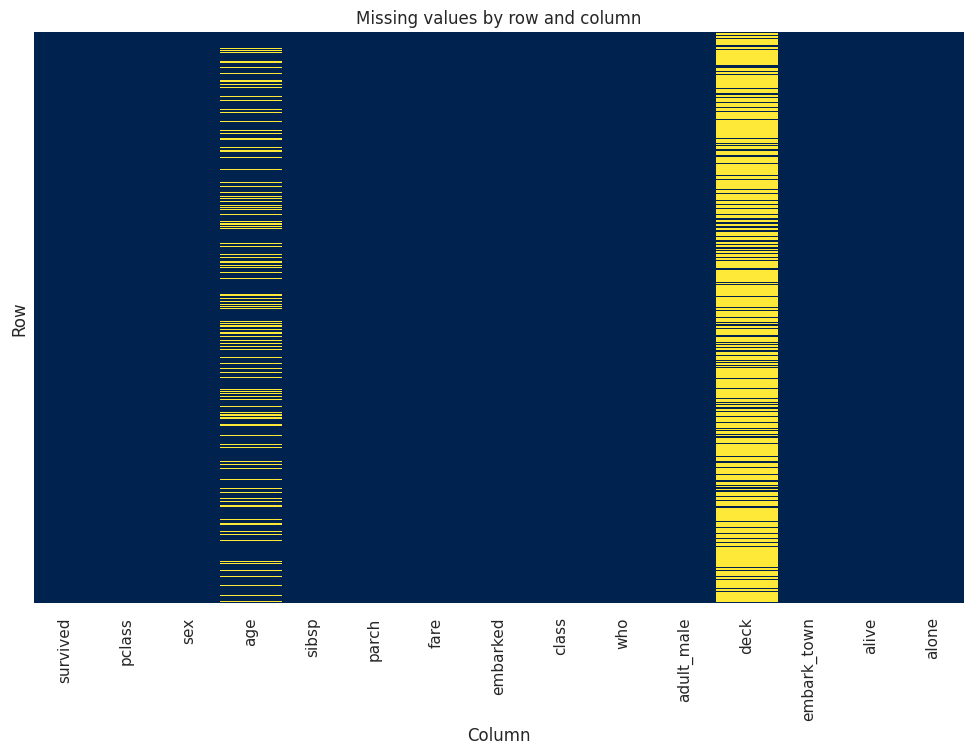

Task 2 passed


In [8]:
# Self-check: Task 2
fig, ax = plot_missingness(raw_df)
assert fig is not None and ax is not None, "Return (fig, ax)"
assert ax.get_title(), "Add a descriptive title"
plt.show()
print("Task 2 passed")


## Guided EDA: Distributions and Relationships

The next cells are analysis cells rather than required functions. Run them, inspect the outputs, and use them in your reflection.


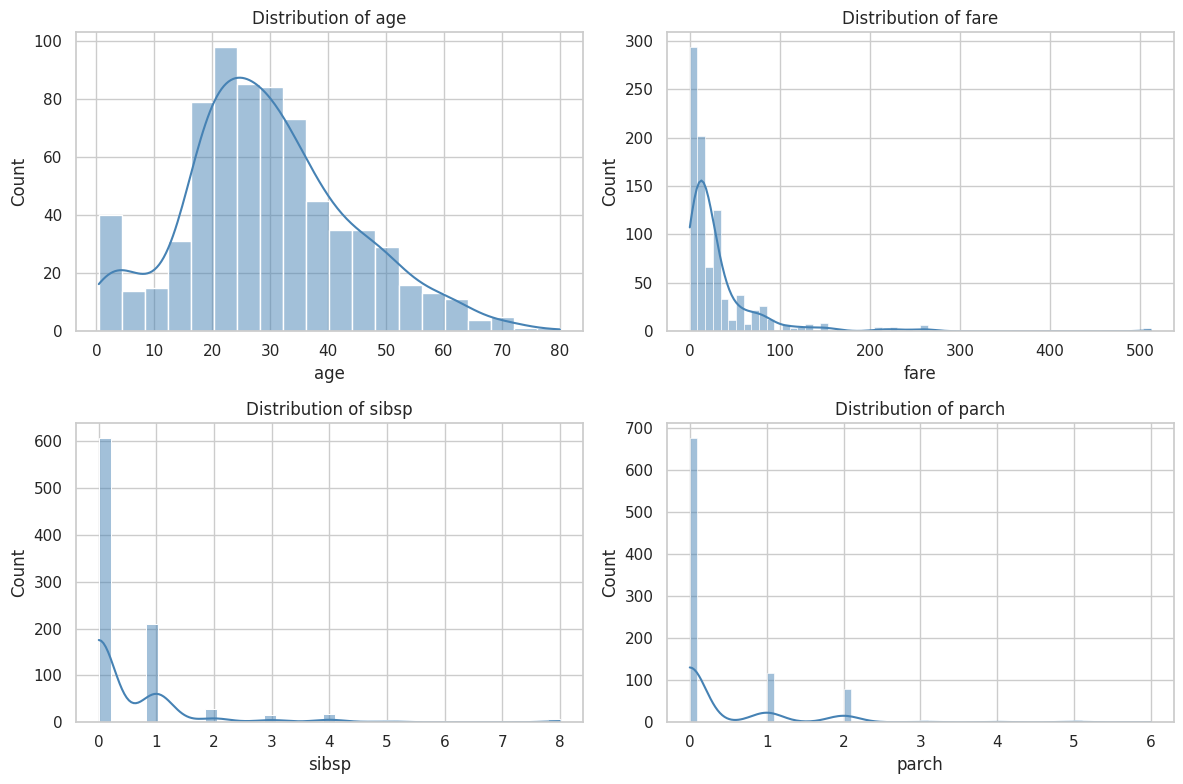

,column,skewness
1,fare,4.787317
2,sibsp,3.695352
3,parch,2.749117
0,age,0.389108


In [9]:
# Numeric distributions
numeric_cols = ["age", "fare", "sibsp", "parch"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, numeric_cols):
    values = raw_df[col].dropna()
    sns.histplot(values, kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

skew_table = (
    raw_df[numeric_cols]
    .skew(numeric_only=True)
    .rename("skewness")
    .reset_index()
    .rename(columns={"index": "column"})
    .sort_values("skewness", ascending=False)
)
skew_table


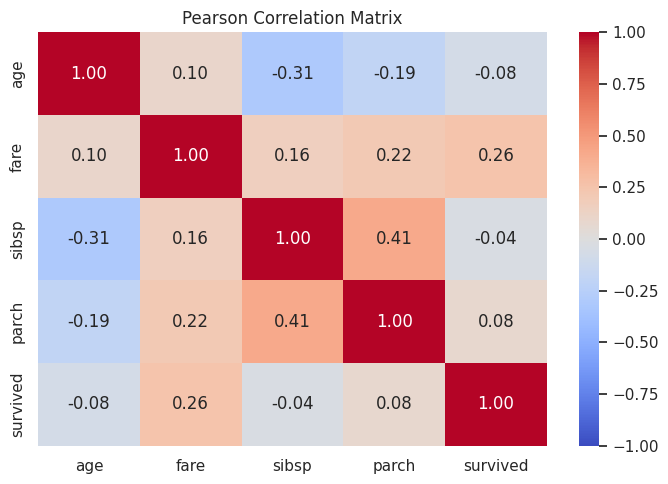

In [10]:
# Correlation heatmap for numeric columns plus target
corr_cols = numeric_cols + ["survived"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(raw_df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()


## Task 3 - Grouped Target Rates

Implement `plot_group_rates(df, target, groupby_cols)`.

For each grouping column, compute the mean target value and the group size. Return three objects:

```python
fig, axes, summary
```

`summary` must be a tidy dataframe with columns:

- `feature`
- `group`
- `rate`
- `count`

Each plot should show one bar per group and annotate the group count.


In [11]:
def plot_group_rates(df: pd.DataFrame, target: str, groupby_cols: list[str]):
    """Plot target rate by group and return (fig, axes, summary)."""
    fig, axes = plt.subplots(1, len(groupby_cols), figsize=(5 * len(groupby_cols), 4), squeeze=False)
    axes = axes.ravel()
    summaries = []

    for ax, feature in zip(axes, groupby_cols):
        grouped = (
            df.groupby(feature, dropna=False)[target]
            .agg(rate="mean", count="size")
            .reset_index()
        )
        grouped["feature"] = feature
        grouped["group"] = grouped[feature].map(lambda value: "Missing" if pd.isna(value) else str(value))

        x_positions = np.arange(len(grouped))
        ax.bar(x_positions, grouped["rate"].to_numpy(dtype=float), color="#4c78a8")
        ax.set_xticks(x_positions)
        ax.set_xticklabels(grouped["group"].tolist(), rotation=30, ha="right")
        ax.set_title(f"{target} rate by {feature}")
        ax.set_xlabel(feature)
        ax.set_ylabel(f"Mean {target}")
        ax.set_ylim(0, 1)

        summaries.append(grouped[["feature", "group", "rate", "count"]])

    fig.tight_layout()
    summary = pd.concat(summaries, ignore_index=True)
    return fig, axes, summary


TypeError: 'value' must be an instance of str or bytes, not a float

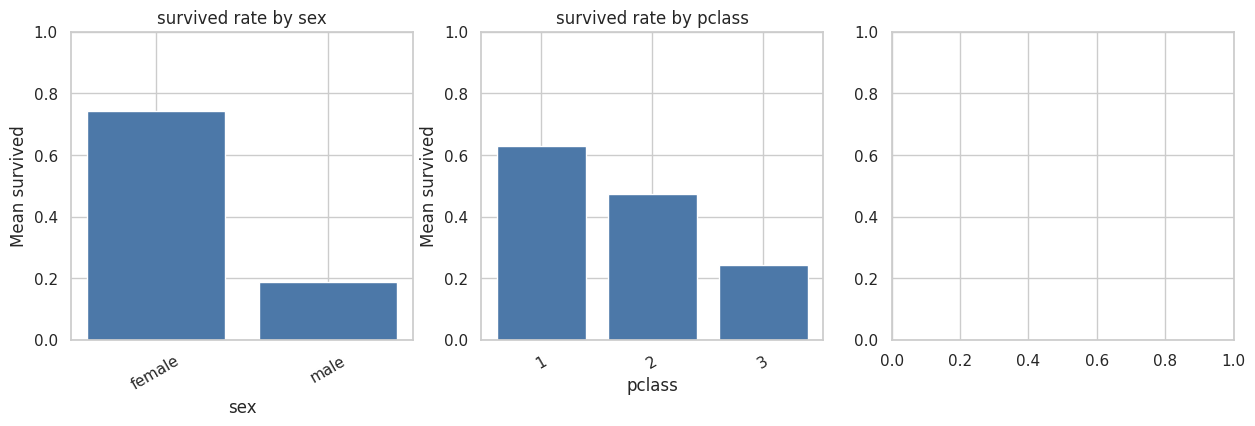

In [12]:
# Self-check: Task 3
fig, axes, rate_summary = plot_group_rates(raw_df, target="survived", groupby_cols=["sex", "pclass", "embarked"])

assert fig is not None and axes is not None, "Return fig and axes"
assert isinstance(rate_summary, pd.DataFrame), "summary must be a DataFrame"
assert {"feature", "group", "rate", "count"}.issubset(rate_summary.columns)
assert rate_summary["rate"].between(0, 1).all(), "Rates should be proportions between 0 and 1"
assert rate_summary["count"].gt(0).all(), "Each displayed group should have a positive count"

plt.show()
print("Task 3 passed")
rate_summary


## Task 4 - Titanic Cleaning Pipeline

Implement `clean_titanic(df)`.

Rules:

1. Work on a copy; do not mutate the input dataframe.
2. Fill missing `age` using grouped median by `(pclass, sex)`.
3. If a grouped median is unavailable, fall back to the global median age.
4. Fill missing `embarked` and `embark_town` with their modes.
5. Drop `deck`, because it is mostly missing.

This function is dataset-specific. It is acceptable that it assumes Titanic column names.


In [13]:
def clean_titanic(df: pd.DataFrame) -> pd.DataFrame:
    """Return a cleaned copy of the Titanic dataframe."""
    clean = df.copy()

    if {"pclass", "sex", "age"}.issubset(clean.columns):
        group_medians = clean.groupby(["pclass", "sex"])["age"].transform("median")
        clean["age"] = clean["age"].fillna(group_medians).fillna(clean["age"].median())

    for column in ["embarked", "embark_town"]:
        if column in clean.columns and clean[column].isna().any():
            modes = clean[column].mode(dropna=True)
            if not modes.empty:
                clean[column] = clean[column].fillna(modes.iloc[0])

    if "deck" in clean.columns:
        clean = clean.drop(columns=["deck"])

    return clean


In [14]:
# Self-check: Task 4
clean_df = clean_titanic(raw_df)

assert clean_df is not raw_df, "Return a copy; do not mutate the input"
assert raw_df["age"].isna().sum() > 0, "The raw dataframe should remain unchanged"
assert clean_df["age"].isna().sum() == 0, "All ages should be imputed"
assert clean_df["embarked"].isna().sum() == 0, "embarked should be imputed"
assert clean_df["embark_town"].isna().sum() == 0, "embark_town should be imputed"
assert "deck" not in clean_df.columns, "deck should be dropped"

# Toy dataframe: catches global-median-only imputation.
tiny = pd.DataFrame({
    "pclass": [1, 1, 3, 3],
    "sex": ["female", "female", "male", "male"],
    "age": [40.0, np.nan, 18.0, np.nan],
    "embarked": ["S", np.nan, "C", "C"],
    "embark_town": ["Southampton", np.nan, "Cherbourg", "Cherbourg"],
    "deck": [np.nan, np.nan, np.nan, np.nan],
})
tiny_clean = clean_titanic(tiny)
assert tiny_clean.loc[1, "age"] == 40.0, "Use grouped age median when available"
assert tiny_clean.loc[3, "age"] == 18.0, "Use grouped age median when available"

print("Task 4 passed")
clean_df.head()


Task 4 passed


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


## Task 5 - Titanic Feature Engineering

Implement `add_titanic_features(df)`.

Add:

- `family_size = sibsp + parch + 1`
- `is_alone = 1` when `family_size == 1`, otherwise `0`
- `age_group` using `AGE_BINS` and `AGE_LABELS`
- `title`, extracted from `name`, keeping `Mr`, `Mrs`, `Miss`, `Master`, and mapping all other titles to `Rare`

Return a copy with the new columns added.


In [15]:
def add_titanic_features(df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy with Titanic-specific engineered features."""
    featured = df.copy()

    featured["family_size"] = featured["sibsp"] + featured["parch"] + 1
    featured["is_alone"] = (featured["family_size"] == 1).astype(int)
    featured["age_group"] = pd.cut(
        featured["age"],
        bins=AGE_BINS,
        labels=AGE_LABELS,
        include_lowest=True,
    )

    if "name" in featured.columns:
        extracted_titles = featured["name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
        featured["title"] = extracted_titles.where(extracted_titles.isin(COMMON_TITLES), "Rare")
    else:
        featured["title"] = "Rare"

    return featured


In [16]:
# Self-check: Task 5
feature_df = add_titanic_features(clean_df)

for col in ["family_size", "is_alone", "age_group", "title"]:
    assert col in feature_df.columns, f"Missing engineered column: {col}"

assert feature_df is not clean_df, "Return a copy; do not mutate the input"
assert feature_df["family_size"].equals(feature_df["sibsp"] + feature_df["parch"] + 1)
assert set(feature_df["is_alone"].unique()).issubset({0, 1})
assert feature_df.loc[feature_df["family_size"] == 1, "is_alone"].eq(1).all()
assert feature_df["title"].isin(["Mr", "Mrs", "Miss", "Master", "Rare"]).all()
assert feature_df["age_group"].isna().sum() == 0

print("Task 5 passed")
feature_df[["family_size", "is_alone", "age_group", "title"]].head()


KeyError: 'name'

## Final Analysis Outputs

Run these cells after all functions pass. These are the outputs your submitted notebook should contain.


In [17]:
# 1. Final audit table
audit_dataframe(raw_df)


,column,dtype,n_missing,pct_missing,n_unique,sample_values
0,deck,category,688,77.216611,7,"[C, C, E]"
1,age,float64,177,19.865320,88,"[22.0, 38.0, 26.0]"
2,embark_town,str,2,0.224467,3,"[Southampton, Cherbourg, Southampton]"
3,embarked,str,2,0.224467,3,"[S, C, S]"
4,adult_male,bool,0,0.000000,2,"[True, False, False]"
5,alive,str,0,0.000000,2,"[no, yes, yes]"
6,alone,bool,0,0.000000,2,"[False, False, True]"
7,class,category,0,0.000000,3,"[Third, First, Third]"
8,fare,float64,0,0.000000,248,"[7.25, 71.2833, 7.925]"
9,parch,int64,0,0.000000,7,"[0, 0, 0]"


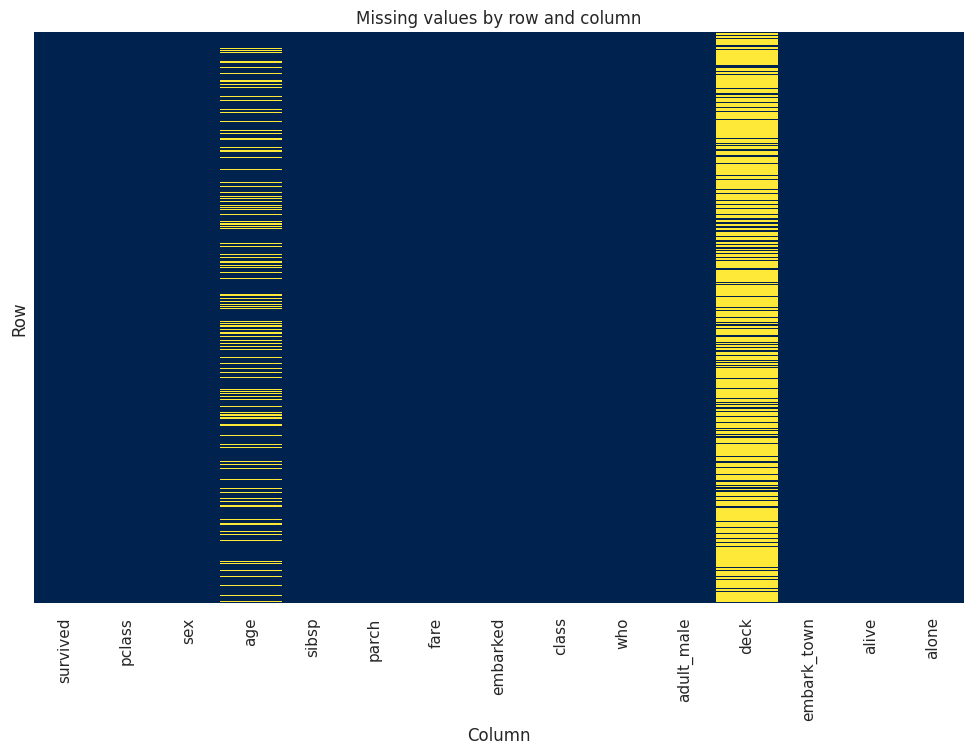

In [18]:
# 2. Missingness heatmap
plot_missingness(raw_df)
plt.show()


TypeError: 'value' must be an instance of str or bytes, not a float

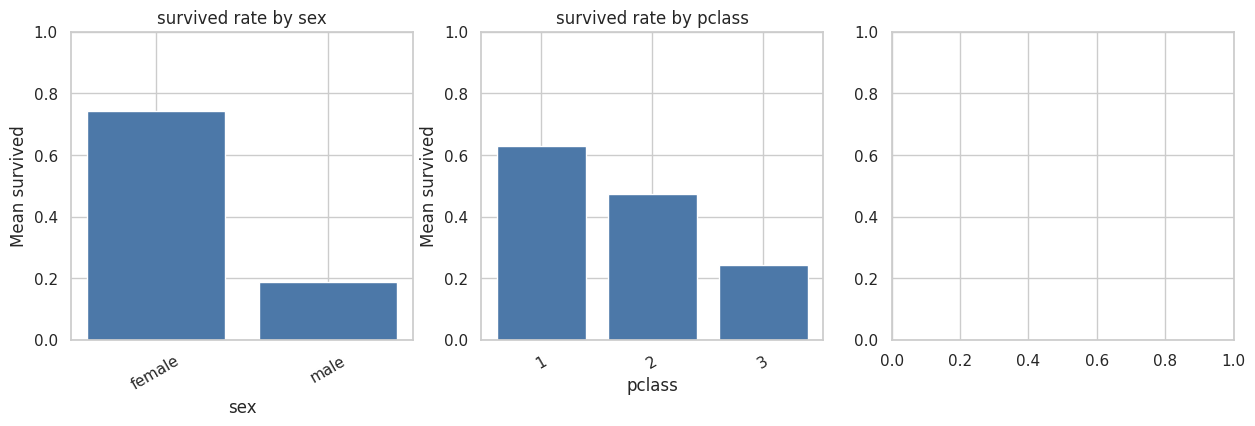

In [19]:
# 3. Outcome rates for original variables
plot_group_rates(raw_df, "survived", ["sex", "pclass", "embarked"])
plt.show()


In [20]:
# 4. Outcome rates for engineered variables
plot_group_rates(feature_df, "survived", ["title", "age_group", "is_alone"])
plt.show()


NameError: name 'feature_df' is not defined

## Reflection

Answer briefly, but concretely.

1. Which missing-value decision is most debatable in this notebook, and why?
2. Which engineered feature seems most useful for understanding survival? What output supports your answer?
3. Which of the three reusable EDA helpers might you reuse in a later week?


## Challenge Tracks Optional

Choose zero, one, or more.

### Track A - Extension
Apply `audit_dataframe`, `plot_missingness`, and `plot_group_rates` to another seaborn dataset such as `penguins` or `tips`. Write two sentences about what changed.

### Track B - Robustness
Improve one required function so it handles an awkward case gracefully, such as an empty dataframe, an all-missing column, or missing group labels.

### Track C - Product
Create a compact Markdown or HTML report containing the audit table, top missing columns, and two saved figures.


In [ ]:
# Optional challenge workspace
# Your code here
